In [2]:
import pandas as pd

In [3]:
adm = pd.read_csv(r'C:\Users\sathv\OneDrive\Desktop\MIMIC DEMO\mimic-iv-clinical-database-demo-2.2\mimic-iv-clinical-database-demo-2.2\hosp\admissions.csv.gz')

In [4]:
adm.shape


(275, 16)

In [5]:
adm.info()

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            275 non-null    int64
 1   hadm_id               275 non-null    int64
 2   admittime             275 non-null    str  
 3   dischtime             275 non-null    str  
 4   deathtime             15 non-null     str  
 5   admission_type        275 non-null    str  
 6   admit_provider_id     275 non-null    str  
 7   admission_location    275 non-null    str  
 8   discharge_location    233 non-null    str  
 9   insurance             275 non-null    str  
 10  language              275 non-null    str  
 11  marital_status        263 non-null    str  
 12  race                  275 non-null    str  
 13  edregtime             182 non-null    str  
 14  edouttime             182 non-null    str  
 15  hospital_expire_flag  275 non-null    int64
dtypes: int64(3), str(13

In [6]:
adm['hospital_expire_flag'].describe()

count    275.000000
mean       0.054545
std        0.227505
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: hospital_expire_flag, dtype: float64

<Axes: xlabel='hospital_expire_flag'>

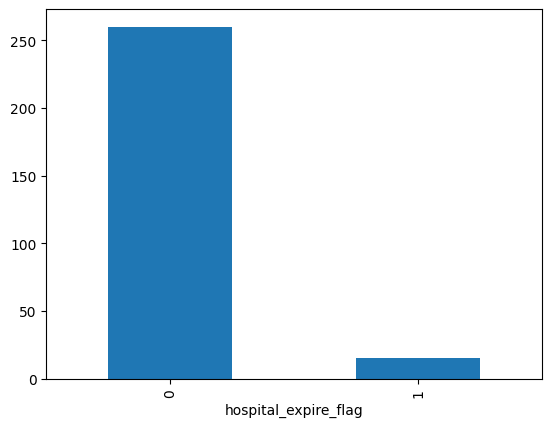

In [7]:
adm['hospital_expire_flag'].value_counts().plot(kind = 'bar')

In [8]:
adm['hospital_expire_flag'].value_counts()

hospital_expire_flag
0    260
1     15
Name: count, dtype: int64

In [9]:
repeat_patients = adm.groupby('subject_id')['hadm_id'].count().sort_values(ascending=False)

multiple_adm = repeat_patients[repeat_patients > 1]

In [10]:
import matplotlib.pyplot as plt 

<Axes: xlabel='subject_id'>

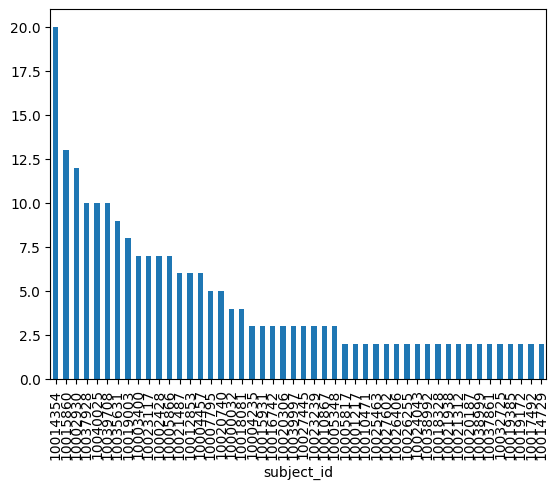

In [11]:
multiple_adm.plot(kind='bar')

In [12]:
multiple_adm.describe()

count    48.000000
mean      4.645833
std       3.772744
min       2.000000
25%       2.000000
50%       3.000000
75%       6.250000
max      20.000000
Name: hadm_id, dtype: float64

In [13]:
adm['multiple_adm'] = adm['subject_id'].map(multiple_adm)

In [14]:
pd.crosstab(adm["admission_type"],adm["multiple_adm"])

multiple_adm,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,12.0,13.0,20.0
admission_type,,,,,,,,,,,,
AMBULATORY OBSERVATION,0,1,0,0,2,0,0,1,1,0,0,0
DIRECT EMER.,2,1,0,0,1,1,1,4,0,1,1,1
DIRECT OBSERVATION,0,1,0,2,3,0,0,0,1,0,0,0
ELECTIVE,2,1,0,0,1,0,2,2,1,0,0,0
EU OBSERVATION,2,3,0,2,1,3,0,0,3,7,3,6
EW EMER.,17,6,5,3,8,13,4,0,13,2,5,4
OBSERVATION ADMIT,6,8,0,0,0,7,1,2,10,0,3,7
SURGICAL SAME DAY ADMISSION,5,2,1,0,2,1,0,0,0,0,0,0
URGENT,6,4,2,3,0,3,0,0,1,2,1,2


In [15]:
pd.crosstab(
    adm["admission_type"],
    adm["multiple_adm"],
    normalize='index'
)

multiple_adm,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,12.0,13.0,20.0
admission_type,,,,,,,,,,,,
AMBULATORY OBSERVATION,0.000000,0.200000,0.000000,0.000000,0.400000,0.000000,0.000000,0.200000,0.200000,0.000000,0.000000,0.000000
DIRECT EMER.,0.153846,0.076923,0.000000,0.000000,0.076923,0.076923,0.076923,0.307692,0.000000,0.076923,0.076923,0.076923
DIRECT OBSERVATION,0.000000,0.142857,0.000000,0.285714,0.428571,0.000000,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000
ELECTIVE,0.222222,0.111111,0.000000,0.000000,0.111111,0.000000,0.222222,0.222222,0.111111,0.000000,0.000000,0.000000
EU OBSERVATION,0.066667,0.100000,0.000000,0.066667,0.033333,0.100000,0.000000,0.000000,0.100000,0.233333,0.100000,0.200000
EW EMER.,0.212500,0.075000,0.062500,0.037500,0.100000,0.162500,0.050000,0.000000,0.162500,0.025000,0.062500,0.050000
OBSERVATION ADMIT,0.136364,0.181818,0.000000,0.000000,0.000000,0.159091,0.022727,0.045455,0.227273,0.000000,0.068182,0.159091
SURGICAL SAME DAY ADMISSION,0.454545,0.181818,0.090909,0.000000,0.181818,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URGENT,0.250000,0.166667,0.083333,0.125000,0.000000,0.125000,0.000000,0.000000,0.041667,0.083333,0.041667,0.083333


In [16]:
adm.groupby('admission_type')['multiple_adm'].mean().sort_values(ascending=False).head()

admission_type
EU OBSERVATION            10.766667
OBSERVATION ADMIT          8.863636
DIRECT EMER.               8.384615
EW EMER.                   6.962500
AMBULATORY OBSERVATION     6.800000
Name: multiple_adm, dtype: float64